### Initialization

Note: some notebooks were generated outside of this workflow by merging outputs from 01-Data.ipynb (e.g., UMAP_input.csv, test.csv, and ec-cofactor.csv)

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
DATA_DIR = "~/Desktop/Projects/media-prediction/" #Replace with your data directory
RANDOM_SEED = 26

### Input

In [3]:
### INPUT organism of interest ###

# Upload test case (.csv with columns ["filename", "ec"])
test_df = pd.read_csv(os.path.join(DATA_DIR, "data", "test.csv"))

# Select a single test sample if file contains multiple
bin = test_df[test_df["filename"].str.contains("Bin.003.fastaCG_F", na=False)]

# Format for UMAP
bin = bin[["filename", "ec"]].value_counts().reset_index()
test = bin.pivot(index=["filename"], columns="ec", values="count").fillna(0.0)

test.head()

ec,1.11.1.15,1.15.1.1,1.2.7.3,1.3.1.98,2.1.1.170,2.1.1.177,2.1.1.192,2.1.1.193,2.1.1.198,2.1.1.199,...,6.1.1.2,6.1.1.20,6.1.1.3,6.1.1.4,6.1.1.6,6.1.1.7,6.1.1.9,6.3.5.6,7.1.2.2,7.4.2.8
filename,,,,,,,,,,,,,,,,,,,,,
KBase_derived_Bin.003.fastaCG_F_extracted_bins.AssemblySet_DRAM.gff,1,1,1,1,1,1,1,1,1,1,...,1,2,1,1,1,1,1,2,2,1


In [4]:
# Load constructed dataset
df = pd.read_csv(os.path.join(DATA_DIR, "data", "UMAP_input.csv"), low_memory=False)

df.head()

,taxon_id,media_id,1.1.1.1,1.1.1.100,1.1.1.101,1.1.1.102,1.1.1.103,1.1.1.105,1.1.1.107,1.1.1.108,...,7.6.2.12,7.6.2.13,7.6.2.14,7.6.2.15,7.6.2.16,7.6.2.2,7.6.2.5,7.6.2.7,7.6.2.8,7.6.2.9
0,100.0,J346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100.0,J386,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100225.0,J233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1002526.0,J22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1004166.0,1a,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### UMAP (unsupervised)
UMAP is used to reduce dimensionality and map the test organism to the metabolic space of the training dataset. Use this in combination with the K-Nearest Neighbors to visualize how closely your organism fits with the training dataset to inform media predictions.

#### UMAP model

In [5]:
# UMAP dimensionality reduction
import umap

model = umap.UMAP(      
        metric="jaccard",
        n_epochs=500,
        random_state=RANDOM_SEED,
        n_jobs=1,
        n_components=20, 
        n_neighbors=40, 
        min_dist=0.1 
        )

# Fit/transform data using UMAP
X_train = df.drop(["taxon_id", "media_id"], axis=1)
X_train_transformed = model.fit_transform(X_train)

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\pynndescent\pynndescent_.py:939: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\umap\umap_.py:127: UserWarning: A few of your vertices were disconnected from the manifold.  This shouldn't cause problems.
Disconnection_distance = 1 has removed 3699 edges.
It has only fully disconnected 60 vertices.
Use umap.utils.disconnected_vertices() to identify them.
  warn(


In [6]:
# Check disconnected vertices

nan_rows = np.isnan(X_train_transformed).any(axis=1)
n_samples = X_train_transformed.shape[0]
n_nan_rows = np.isnan(X_train_transformed).any(axis=1).sum()
percent_nan_rows = 100 * n_nan_rows / n_samples

print(percent_nan_rows, "percent of embedded samples are nan (disconnected vertices / total samples).")

0.7088846880907372 percent of embedded samples are nan (disconnected vertices / total samples).


#### Clustering

In [7]:
# Cluster embedding
from sklearn.cluster import KMeans

X_train_clean = X_train_transformed[~nan_rows]
clusterer = KMeans(n_clusters=14, n_init=50, random_state=RANDOM_SEED)
cluster_labels = clusterer.fit_predict(X_train_clean)

# Clustering performance
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_train_clean, cluster_labels)
print(clusterer.labels_.max()+1, "KMeans training clusters")
print(f"Average Silhouette Score on KMeans clusters: {silhouette_avg}")

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


14 KMeans training clusters
Average Silhouette Score on KMeans clusters: 0.7286314964294434


#### Transform test case

In [8]:
# Resize test case to include all of the same EC numbers as the training dataset
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

train = df.copy()
train = train.drop(["taxon_id", "media_id"], axis=1)

for col in train.columns:
    if col not in test.columns:
        test[col] = 0

test = test[train.columns]

# Transform the test case with UMAP
test_embedding = model.transform(test)

#### Feature Importance

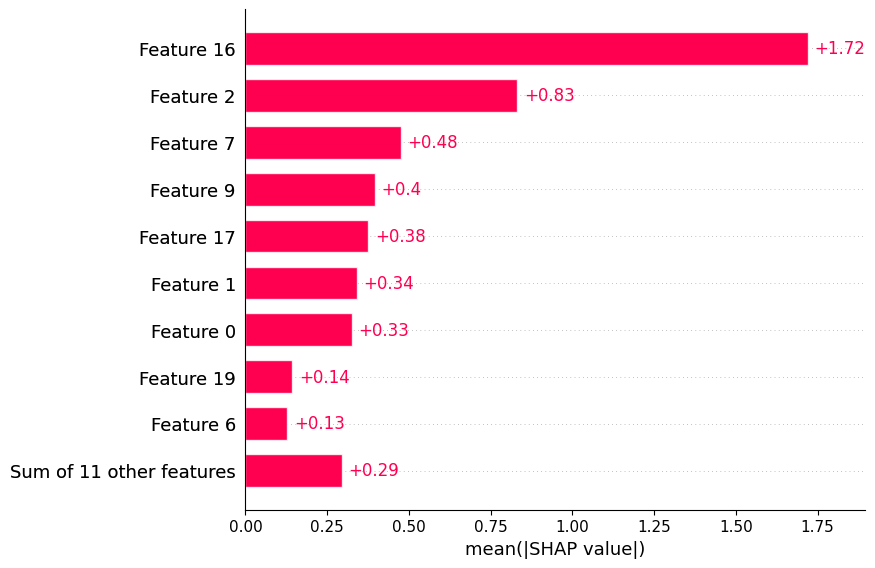

In [9]:
# UMAP Features
import xgboost
import shap

XG_train = X_train_clean
yG_train = cluster_labels

model = xgboost.XGBRegressor().fit(XG_train, yG_train)
explainer = shap.Explainer(model)
shap_values = explainer(XG_train)

shap.plots.initjs()
shap.plots.bar(shap_values)

#### Visualization

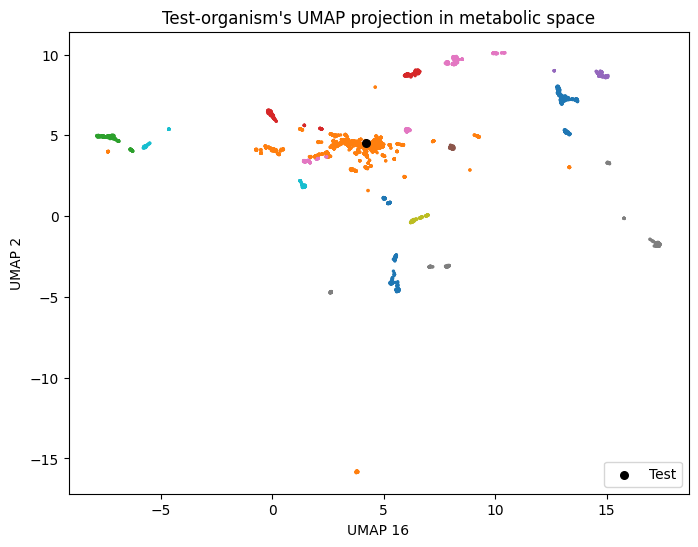

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Reference organisms from constructed dataset
plt.scatter(X_train_clean[:,15], X_train_clean[:,1], c=cluster_labels, cmap="tab10", s=2) 
    # Components 16 and 2 determined highest importance via XGBoost/Shap

# Test sample
plt.scatter(test_embedding[0, 0], test_embedding[0, 1], c="black", s=30, label="Test")

plt.xlabel("UMAP 16")
plt.ylabel("UMAP 2")
plt.title("Test-organism's UMAP projection in metabolic space")
plt.legend(loc="lower right")
plt.show()

### Prediction

#### Nearest neighbors (unsupervised)

In [11]:
# Function for finding nearest neighbors via the jaccard metric (uses original dataset)
from sklearn.neighbors import NearestNeighbors

def get_nearest_neighbors(X_train, new_sample, k=5, metric="jaccard", algorithm="auto"):
    nn = NearestNeighbors(n_neighbors=k, metric="jaccard")
    nn.fit(train)
    distances, indices = nn.kneighbors(test)
    
    return distances[0], indices[0]

In [12]:
# Return nearest neighbors
distances, indices = get_nearest_neighbors(train, test, k=5)
nearest_info = df.iloc[indices][['taxon_id', 'media_id']].copy()

print(nearest_info)
neighbors = pd.DataFrame(nearest_info)

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\metrics\pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


       taxon_id media_id
6419    47834.0    1076b
362   1136073.0    1076b
6420    47835.0    1076b
5422   358687.0     J346
5357   351343.0     J346


#### Nearest neighbor media

In [13]:
# Show the media of the nearest neighboring taxa based on their metabolic characteristics
media_df = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete.csv"), low_memory=False) #"mediadive-complete-explo.csv"
prediction = pd.merge(left=neighbors, right=media_df, on="media_id", how="left")
prediction = prediction.drop(["taxon_id"], axis=1)

# Occurrence column shows how many of the neighbors utilize each media type
prediction["occurrence"] = prediction["media_id"].map(prediction["media_id"].value_counts(normalize=True))
prediction = prediction.drop_duplicates()

prediction.head()

,media_id,solutions,solution_names,components,component_ids,component_gL,steps,sub_solutions,solution_ids,solution_ml,occurrence
0,1076b,[2173],['Main sol. 1076b'],"['PPLO broth', 'Tryptone', 'Bacto peptone', 'D...","[953, 71, 19, 4, 958, 1680, 16, 954, 960, 5, 3...","[3.5, 10, 5, None, 0.2, None, 0.4, None, None,...",[[{'step': 'The difference between this medium...,[],[],[],0.6
3,J346,[4066],['Main sol. J346'],"['Yeast extract', 'Proteose peptone no. 3', 'C...","[16, 316, 101, 5, 199, 438, 10, 8, 3, 4]","[0.5, 0.5, 0.5, 0.5, 0.5, 0.3, 0.3, 0.05, 15, ...","[[{'step': 'Adjust pH to 7.2.'}, {'step': 'Com...",[],[],[],0.4


#### Cofactor comparison

In [14]:
# Load training set EC and cofactor info
train_co = pd.read_csv(os.path.join(DATA_DIR, "data", "ec-cofactor.csv"))
train_co.head()

,media_id,taxon_id,source,ec,CofactorFinal
0,1a,1886637.0,uniprot,1.13.11.74,Fe
1,1a,1886637.0,uniprot,1.13.11.76,Fe
2,1a,1886637.0,uniprot,1.1.9.1,Ca
3,1a,1886637.0,uniprot,1.1.9.1,Fe
4,1a,1886637.0,uniprot,1.14.12.15,Fe


In [15]:
# Align test case cofactor info based on EC numbers
test_co = bin[["filename", "ec"]]
tr_co = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "cofactors-taxa.csv"), low_memory=False)
tr_co = tr_co[["Query EC", "CofactorFinal"]]
tr_co = tr_co.rename(columns={"Query EC":"ec"})
merge_co = pd.merge(left=test_co, right=tr_co, on="ec", how="left")

# Focus on metals / trace elements
metals = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "metals-list.csv"))
metals_list = metals["Metals"].to_list()
filter = merge_co["CofactorFinal"].isin(metals_list)
test_co = merge_co[filter]

test_co.head()

,filename,ec,CofactorFinal
0,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Fe
2,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Mg
3,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,metal
4,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Zn
5,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Mn


In [16]:
# Dictionary for undefined metals
dictionary = {"a monovalent": "UM", "metal": "UM"}

# Calculating relative abundances of cofactors between training vs. test case
def summarize_cofactors(df, label):
    return (
        df.assign(
            CofactorFinal=df["CofactorFinal"].replace(dictionary, regex=True)
        )
        .value_counts("CofactorFinal", normalize=True)
        .rename("ra")
        .reset_index()
        .assign(
            ct=lambda x: (x["ra"] * len(df)).round().astype(int),
            Set=label
        )
        [["CofactorFinal", "ct", "ra", "Set"]]
    )

# Storing dataframe for our relative abundances
counts = pd.concat([summarize_cofactors(train_co, "Training"), summarize_cofactors(test_co, "Test")], ignore_index=True)
counts = counts.sort_values("ct", ascending=False)

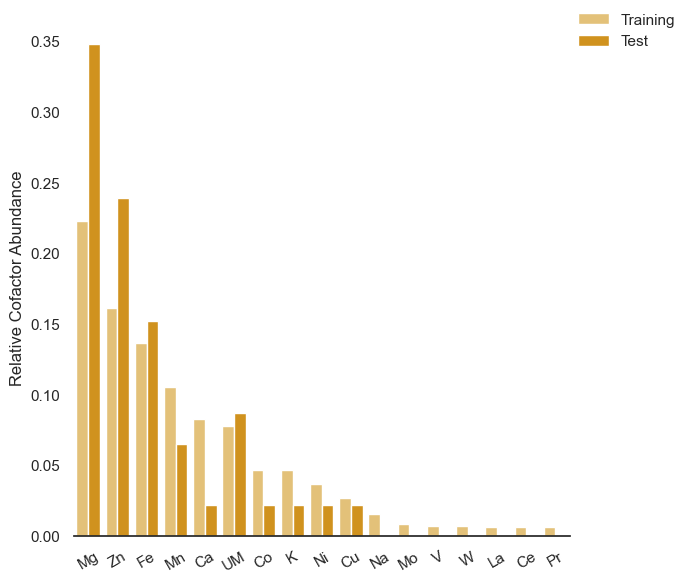

In [17]:
import seaborn as sns
sns.set_theme(style="white")

colors = ["#f5c767", "#ee9b00"]

# Draw a nested barplot by species and sex
g = sns.catplot(
    data=counts, kind="bar",
    x="CofactorFinal", y="ra", hue="Set", 
    palette=colors, alpha=1, height=6
)

g.despine(left=True)
g.set_axis_labels("", "Relative Cofactor Abundance")
g.tick_params(axis='x', rotation=30)
g.legend.set_loc("upper right")
g.legend.set_title("")